In [1]:
# K‑Nearest Neighbors (KNN) is a simple, non‑parametric algorithm that classifies or predicts values based on the closest data points in the training set. 
# It works by measuring similarity (usually distance) between points and assigning the majority class or average value of the nearest neighbors.

In [2]:
import numpy as np
import pandas as pd 

df = pd.read_csv('breast_cancer.csv')
df.drop(columns=['id','Unnamed: 32'],inplace=True)
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
df.shape

(569, 31)

In [4]:
# Encode diagnosis (M=1, B=0)
df['diagnosis'] = df['diagnosis'].map({'M':1, 'B':0})
print(df['diagnosis'])

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: diagnosis, Length: 569, dtype: int64


In [5]:
# Features (drop id and diagnosis)
X = df.drop(columns=['diagnosis'], axis =1)
y = df['diagnosis']

In [6]:
X.shape

(569, 30)

In [7]:
y.shape

(569,)

In [8]:
# Train Test Split the Data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [9]:
# Feature Scaling is Must
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
# Build KNN Model

from sklearn.neighbors import KNeighborsClassifier

# Try k=5 neighbors
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Predictions
y_pred = knn.predict(X_test_scaled)

In [11]:
# Evaluate Model

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9649122807017544

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       107
           1       1.00      0.91      0.95        64

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.97      0.96      0.96       171


Confusion Matrix:
 [[107   0]
 [  6  58]]


Accuracy: 0.9649122807017544


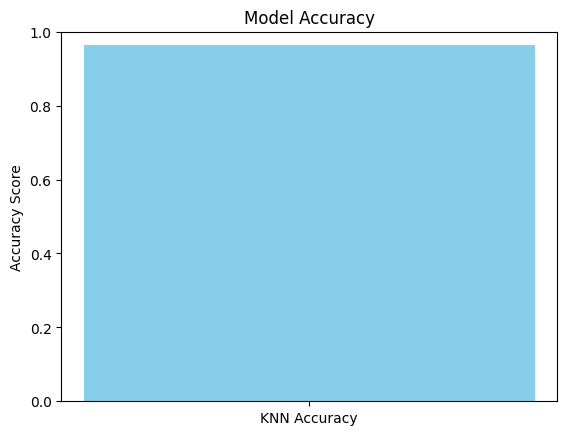

In [12]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Plot accuracy as a bar
import matplotlib.pyplot as plt

plt.bar(["KNN Accuracy"], [accuracy], color="skyblue")
plt.ylim(0,1)
plt.title("Model Accuracy")
plt.ylabel("Accuracy Score")
plt.show()

              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97       107
   Malignant       1.00      0.91      0.95        64

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.97      0.96      0.96       171



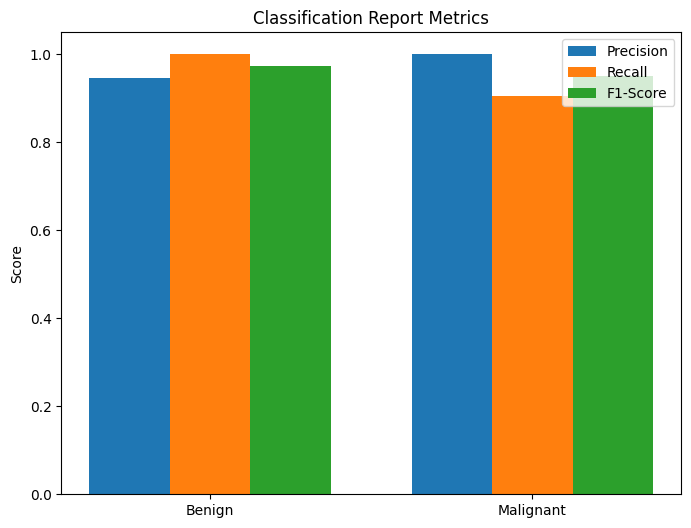

In [13]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, target_names=["Benign","Malignant"])
print(report)

# Convert report to dictionary for plotting
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred)

labels = ["Benign","Malignant"]
x = range(len(labels))

plt.figure(figsize=(8,6))
plt.bar(x, precision, width=0.25, label="Precision", align="center")
plt.bar([i+0.25 for i in x], recall, width=0.25, label="Recall", align="center")
plt.bar([i+0.50 for i in x], f1, width=0.25, label="F1-Score", align="center")

plt.xticks([i+0.25 for i in x], labels)
plt.ylabel("Score")
plt.title("Classification Report Metrics")
plt.legend()
plt.show()

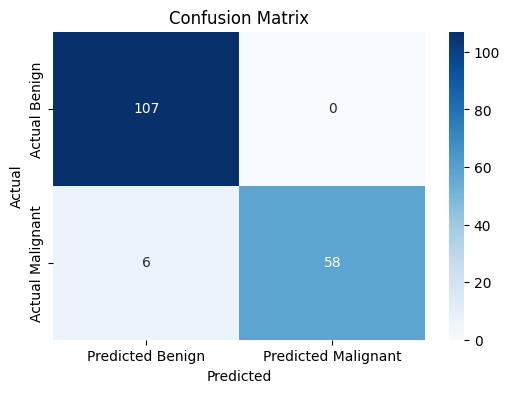

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Predicted Benign","Predicted Malignant"],
            yticklabels=["Actual Benign","Actual Malignant"])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

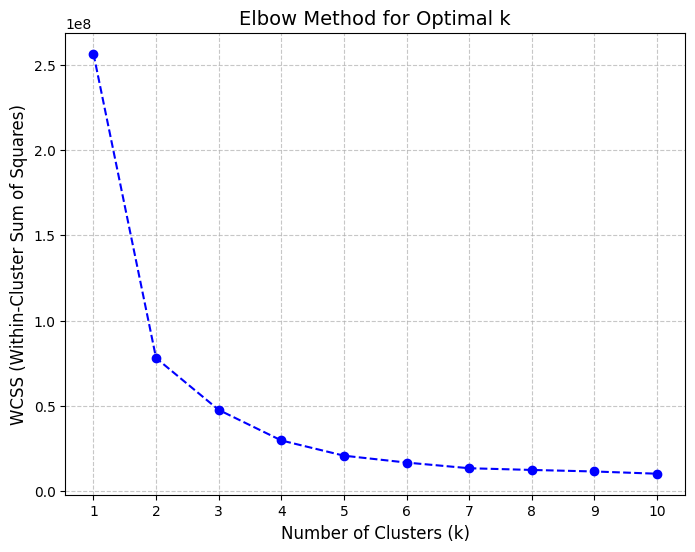

In [15]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)   # X is your feature matrix
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal k', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
plt.xticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Using KNN on Customer_Chrun Dataset

In [ ]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 2: Load dataset
df = pd.read_csv("Customer_Churn.csv")
# print(df.head())
# print(df.info())
print(df.isnull().sum())

# Numeric columns → fill with median
for col in df.select_dtypes(include=['float64','int64']).columns:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns → fill with mode
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Step 3: Define features and target
X = df.drop("Churn", axis=1)   # assuming 'Churn' is the target column
y = df["Churn"]

# Step 4: Encode categorical predictors
X_encoded = pd.get_dummies(X, drop_first=True)

# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

# Step 6: Scale features (important for KNN distance calculations)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 7: Find optimal K using cross-validation
error_rates = []
k_values = range(1, 10)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    error_rates.append(1 - scores.mean())

plt.plot(k_values, error_rates, marker='o')
plt.xlabel("K value")
plt.ylabel("Error Rate")
plt.title("Error Rate vs. K")
plt.show()

# Step 8: Train final KNN model with optimal K (example: K=7)
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)

# Step 9: Predictions
y_pred = knn.predict(X_test_scaled)

# Step 10: Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      6
TotalCharges        0
Churn               0
dtype: int64


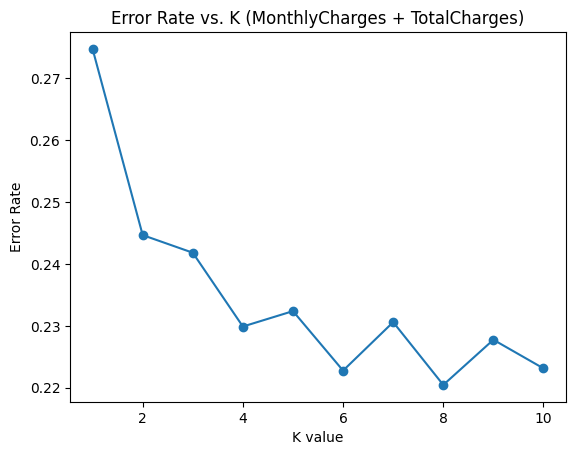

Accuracy: 0.794452347083926
Confusion Matrix:
 [[929 103]
 [186 188]]
Classification Report:
               precision    recall  f1-score   support

          No       0.83      0.90      0.87      1032
         Yes       0.65      0.50      0.57       374

    accuracy                           0.79      1406
   macro avg       0.74      0.70      0.72      1406
weighted avg       0.78      0.79      0.79      1406



In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 1: Load dataset
df = pd.read_csv("Customer_Churn.csv")

# Step 1: Select features
X = df[['MonthlyCharges', 'TotalCharges']]

# Step 1: Select the two numeric columns as a copy
X = df[['MonthlyCharges', 'TotalCharges']].copy()

# Step 2: Convert TotalCharges to numeric safely
X.loc[:, 'TotalCharges'] = pd.to_numeric(X['TotalCharges'], errors='coerce')

# Step 3: Drop rows with NaN
X = X.dropna()

# Step 4: Align target with cleaned X
y = df.loc[X.index, 'Churn']   # replace 'Churn' with the actual target column name

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 5: Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 6: Find optimal K
error_rates = []
k_values = range(1, 11)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    error_rates.append(1 - scores.mean())

plt.plot(k_values, error_rates, marker='o')
plt.xlabel("K value")
plt.ylabel("Error Rate")
plt.title("Error Rate vs. K (MonthlyCharges + TotalCharges)")
plt.show()

# Step 7: Train final model with chosen K (example: K=7)
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)

# Step 8: Predictions
y_pred = knn.predict(X_test_scaled)

# Step 9: Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))